### Load py Packages

In [22]:
import numpy as np
import math
from typing import Iterable, Optional, Union
from scipy.linalg import expm, sqrtm

import scipy
from scipy.sparse.linalg import expm
import random
import scipy.special
import scipy.sparse as sp
import matplotlib.pyplot as plt
import networkx as nx
from networkx import hypercube_graph, star_graph
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.widgets import Slider, CheckButtons

import scipy.sparse as sp
import random

from typing import Dict, List, Tuple, Any, Optional, Union

#from qwalk_simulator_helper import *

### Set Constants

In [243]:
MAX_TIME = 160

### Generate Directed Tree (Binary Unidirectional)

In [28]:
from typing import Dict, List, Tuple, Optional

def gen_binary_tree_adjlist_base_directed4(
    n: int,
    *,
    start_id: int = 0,
    directed_to_leaf: bool = True,
    base: Optional[int] = None,   # legacy alias; ignored if start_id is provided
) -> Tuple[Dict[int, List[int]], List[int]]:
    if n < 1:
        raise ValueError("Depth n must be at least 1.")

    # Back-compat with old 'base' param (start_id takes precedence unless explicitly set)
    if base is not None and start_id == 0:
        start_id = int(base)

    num_nodes = (1 << n) - 1  # 2^n - 1
    adj: Dict[int, List[int]] = {start_id + i: [] for i in range(num_nodes)}

    # Only internal nodes have children
    last_internal = (num_nodes - 2) // 2  # -1 when n == 1 (no internal nodes)

    # Add directed edges
    for p in range(last_internal + 1):
        u = start_id + p
        l = start_id + (2*p + 1)
        r = start_id + (2*p + 2)
        if directed_to_leaf:
            # parent -> children
            adj[u].append(l)
            adj[u].append(r)
        else:
            # children -> parent
            adj[l].append(u)
            adj[r].append(u)

    # Leaves are the nodes with no children in the underlying (undirected) tree:
    # i.e., all indices > last_internal. Works for all n, including n=1.
    leaves = [start_id + i for i in range(last_internal + 1, num_nodes)]

    return adj, leaves



In [30]:
def reverse_tree_direction_alt(
    adj: Dict[Any, List[Any]],
    leaves: List[Any],
    *,
    assume_directed: Optional[bool] = None,
) -> Tuple[Dict[Any, List[Any]], List[Any]]:
    # Collect all nodes, including neighbors and any leaves not present as keys
    nodes = set(adj.keys())
    for u, nbrs in adj.items():
        nodes.update(nbrs)
    nodes.update(leaves)  # ensure all provided leaves exist as nodes

    # Auto-detect directedness if not provided
    directed = assume_directed
    if directed is None:
        directed = False
        for u, nbrs in adj.items():
            for v in nbrs:
                if u not in adj.get(v, []):
                    directed = True
                    break
            if directed:
                break

    # Initialize output dict with all nodes present
    out: Dict[Any, List[Any]] = {u: [] for u in nodes}

    if directed:
        # Reverse every edge u->v -> v->u
        for u, nbrs in adj.items():
            for v in nbrs:
                if u not in out[v]:
                    out[v].append(u)
    else:
        # Undirected: normalize to symmetric (no duplicates)
        for u, nbrs in adj.items():
            for v in nbrs:
                if v not in out[u]:
                    out[u].append(v)
                if u not in out[v]:
                    out[v].append(u)

    # Make sure all leaves appear as keys even if they have no outgoing edges
    for leaf in leaves:
        out.setdefault(leaf, [])

    return out, list(leaves)  # return a shallow copy of the original leaves


In [32]:
def glue_binary_directed_Trees4(
    T1: Dict[Any, List[Any]],
    L1: List[Any],
    T2: Dict[Any, List[Any]],
    L2: List[Any],
    *,
    seed: Optional[int] = None
) -> Tuple[Dict[Any, List[Any]], Any, Any]:

    if seed is not None:
        random.seed(seed)

    if len(L1) != len(L2):
        raise ValueError("L1 and L2 must have the same number of leaves (trees of the same depth).")

    # Infer starts as the min-labeled node in each tree (matches how start_id is used in generators)
    start_node = min(T1.keys())
    end_node   = min(T2.keys())

    # Build glued adjacency (copy, ensure all nodes present)
    glued: Dict[Any, List[Any]] = {u: nbrs[:] for u, nbrs in T1.items()}
    for u, nbrs in T2.items():
        glued[u] = glued.get(u, []) + nbrs[:]

    # Ensure all leaves exist as keys
    for u in L1:
        glued.setdefault(u, [])
    for u in L2:
        glued.setdefault(u, [])

    def add_edge(u, v):
        """Add directed edge u->v if not already present."""
        if v not in glued[u]:
            glued[u].append(v)

    m = len(L1)

    # Trivial case: one leaf per tree → best effort (two opposite edges)
    if m == 1:
        a0, b0 = L1[0], L2[0]
        add_edge(a0, b0)  # T1 -> T2
        add_edge(b0, a0)  # T2 -> T1
        return glued, start_node, end_node

    # Randomize leaf order and build alternating sequence
    L1_pool = L1[:]
    L2_pool = L2[:]
    random.shuffle(L1_pool)
    random.shuffle(L2_pool)

    a0 = L1_pool.pop()
    b0 = L2_pool.pop()
    order: List[Any] = [a0, b0]  # starts T1 -> T2

    # Interleave remaining leaves: ... a1, b1, a2, b2, ...
    while L1_pool and L2_pool:
        order.append(L1_pool.pop())  # T1
        order.append(L2_pool.pop())  # T2

    # Add directed edges along the chain with alternating direction by construction
    for u, v in zip(order, order[1:]):
        add_edge(u, v)

    # Close the alternating cycle (last is from T2) -> (first from T1)
    add_edge(order[-1], order[0])

    return glued, start_node, end_node


### Visualization Functions (Adj List and Adj Matrix)

In [35]:
# ---------------- Visualize Adjacency Matrix ----------------

def _infer_glued_end_node(labels: List[Any]) -> Optional[int]:
    """If labels are ints, include 0, and are non-contiguous, return the first new block start (>0)."""
    if not labels or any(not isinstance(x, int) for x in labels):
        return None
    s = set(labels)
    if 0 not in s:
        return None
    for x in sorted(s):
        if x > 0 and (x - 1) not in s:
            return x
    return None

def _heap_positions(n: int) -> dict:
    """Binary-heap style level layout for nodes 0..n-1."""
    pos = {}
    for i in range(n):
        level = int(np.floor(np.log2(i + 1)))
        level_start = 2**level - 1
        idx_in_level = i - level_start
        nodes_in_level = max(1, 2**level)
        x = (idx_in_level + 1) / (nodes_in_level + 1)
        y = -level
        pos[i] = (x, y)
    return pos

def visualize_adjmatrix(
    A,
    *,
    nodes: Optional[List[Any]] = None,   # labels for indices 0..n-1
    layout: str = "kamada_kawai",        # "kamada_kawai", "spring", "circular", "shell", "random", "planar", "heap"
    node_size: int = 420,
    font_size: int = 9,
    title: Optional[str] = None,
):
    """
    Visualize a graph/tree from an adjacency matrix.

    Coloring rule:
      - If labels are provided, are integers, include 0, and are NON-contiguous (glued-tree pattern),
        color node 0 and the inferred 'end node' (root of 2nd block) green.
      - Otherwise, color leaves green:
          * undirected: degree == 1  (single-node -> green)
          * directed  : out-degree == 0

    Parameters
    ----------
    A : np.ndarray or scipy.sparse matrix
        Adjacency matrix.
    nodes : list[Any] or None
        Optional labels for matrix indices [0..n-1]. If None, labels = indices.
    layout : str
        One of: "kamada_kawai", "spring", "circular", "shell", "random", "planar", "heap".
        "heap" expects nodes labeled 0..n-1 in heap order and draws layered.
    """
    # ---- normalize matrix & infer directedness
    try:
        import scipy.sparse as sp
        is_sparse = sp.issparse(A)
    except Exception:
        sp = None
        is_sparse = False

    if is_sparse:
        A_csr = A.tocsr()
        is_undirected = (A_csr != A_csr.T).nnz == 0
        G = nx.from_scipy_sparse_array(A_csr, create_using=nx.Graph() if is_undirected else nx.DiGraph)
        n = A_csr.shape[0]
    else:
        A_np = np.asarray(A)
        is_undirected = np.allclose(A_np, A_np.T)
        G = nx.from_numpy_array(A_np, create_using=nx.Graph() if is_undirected else nx.DiGraph)
        n = A_np.shape[0]

    # ---- labels
    if nodes is None:
        labels = list(range(n))
    else:
        if len(nodes) != n:
            raise ValueError("Length of `nodes` must match matrix size.")
        labels = list(nodes)

    # Relabel graph to provided labels
    mapping = {i: labels[i] for i in range(n)}
    G = nx.relabel_nodes(G, mapping)

    # ---- layout
    if layout == "heap" and nodes is None:
        # heap positions are for indices 0..n-1; use before relabeling
        pos_idx = _heap_positions(n)
        # map to labels
        pos = {mapping[i]: xy for i, xy in pos_idx.items()}
    else:
        if layout == "kamada_kawai":
            pos = nx.kamada_kawai_layout(G)
        elif layout == "spring":
            pos = nx.spring_layout(G, seed=42)
        elif layout == "circular":
            pos = nx.circular_layout(G)
        elif layout == "shell":
            pos = nx.shell_layout(G)
        elif layout == "random":
            pos = nx.random_layout(G)
        elif layout == "planar":
            try:
                pos = nx.planar_layout(G)
            except Exception:
                pos = nx.spring_layout(G, seed=42)
        elif layout == "heap":
            # If labels provided, we can't compute levels reliably; fall back
            pos = nx.spring_layout(G, seed=42)
        else:
            pos = nx.spring_layout(G, seed=42)

    # ---- decide coloring
    green_nodes = set()
    int_labels = all(isinstance(x, int) for x in G.nodes)
    looks_glued = False
    end_node = None
    if int_labels and (0 in G.nodes):
        end_node = _infer_glued_end_node(list(G.nodes))
        looks_glued = end_node is not None

    if looks_glued:
        green_nodes = {0, end_node}
    else:
        # treat as standard tree/graph: leaves green
        if isinstance(G, nx.DiGraph) and not is_undirected:
            # directed leaves: out-degree 0
            green_nodes = {u for u in G.nodes if G.out_degree(u) == 0} or set(G.nodes)
        else:
            # undirected leaves: degree 1 (single-node -> green)
            if G.number_of_nodes() == 1:
                green_nodes = set(G.nodes)
            else:
                green_nodes = {u for u in G.nodes if G.degree(u) == 1}

    node_colors = ["#2ecc71" if u in green_nodes else "#87CEEB" for u in G.nodes]

    # ---- draw
    plt.figure(figsize=(9, 7))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=node_size,
        node_color=node_colors,
        font_size=font_size,
        edge_color="#777",
        width=1.3,
        arrows=isinstance(G, nx.DiGraph) and not is_undirected
    )
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [37]:
# ---------------- Visualize Adjacency List ----------------

def visualize_adjlist(
    adj: Dict[Any, List[Any]],
    pos: Optional[Dict[Any, Tuple[float, float]]] = None,
    layout: str = "spring",
    node_size: int = 420,
    font_size: int = 9,
    title: Optional[str] = None,
):
    # --- Build graph (auto-detect directedness via reciprocity) ---
    nodes = set(adj.keys())
    for u, nbrs in adj.items():
        nodes.update(nbrs)

    # infer directedness
    directed = False
    for u, nbrs in adj.items():
        for v in nbrs:
            if u not in adj.get(v, []):
                directed = True
                break
        if directed:
            break

    G = nx.DiGraph() if directed else nx.Graph()
    G.add_nodes_from(nodes)
    for u, nbrs in adj.items():
        for v in nbrs:
            if directed or (not G.has_edge(u, v) and not G.has_edge(v, u)):
                G.add_edge(u, v)

    # --- Layout if none provided ---
    if pos is None:
        if layout == "spring":
            pos = nx.spring_layout(G, seed=42)
        elif layout == "kamada_kawai":
            pos = nx.kamada_kawai_layout(G)
        elif layout == "circular":
            pos = nx.circular_layout(G)
        elif layout == "shell":
            pos = nx.shell_layout(G)
        elif layout == "random":
            pos = nx.random_layout(G)
        elif layout == "planar":
            try:
                pos = nx.planar_layout(G)
            except Exception:
                pos = nx.spring_layout(G, seed=42)
        else:
            pos = nx.spring_layout(G, seed=42)

    # --- Decide coloring mode ---
    color_green_nodes = set()
    is_single_node = (G.number_of_nodes() == 1)

    # Heuristic: glued if int labels, contains 0, and labels are non-contiguous (e.g., second tree starts at 10)
    int_labels = all(isinstance(n, int) for n in G.nodes)
    looks_glued = False
    if int_labels and (0 in G.nodes):
        lbls = sorted(G.nodes)
        # non-contiguous if there are missing integers between min and max
        looks_glued = set(lbls) != set(range(min(lbls), max(lbls) + 1))

    if looks_glued:
        end_node = max(G.nodes)  # treat the largest label as the "end"
        color_green_nodes = {0, end_node}
    else:
        # Treat as a single binary tree: leaves green
        if is_single_node:
            color_green_nodes = set(G.nodes)
        else:
            if directed:
                # leaves = out-degree 0
                color_green_nodes = {n for n in G.nodes if G.out_degree(n) == 0}
            else:
                color_green_nodes = {n for n in G.nodes if G.degree(n) == 1}

    # --- Colors & widths ---
    default_node_color = "#87CEEB"  # light blue
    leaf_node_color = "#2ecc71"     # green
    node_colors = [leaf_node_color if n in color_green_nodes else default_node_color for n in G.nodes]

    # Neutral edge styling
    edge_colors = ["#888888"] * G.number_of_edges()
    edge_widths = [1.2] * G.number_of_edges()

    # --- Draw ---
    plt.figure(figsize=(9, 7))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=node_size,
        node_color=node_colors,
        font_size=font_size,
        edge_color=edge_colors,
        width=edge_widths,
        arrows=directed
    )
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


### Convert Tree in different formats (List and Adjacency Matrix)

In [94]:
def _infer_end_node_from_labels(labels: List[Any]) -> Optional[int]:
    if not labels or any(not isinstance(x, int) for x in labels):
        return None
    s = set(labels)
    if 0 not in s:
        return None
    for x in sorted(s):
        if x > 0 and (x - 1) not in s:
            return x
    return None

def _stable_sort_nodes(node_set) -> List[Any]:
    """Sort ints numerically first, then non-ints by string repr for stability."""
    ints = [x for x in node_set if isinstance(x, int)]
    others = [x for x in node_set if not isinstance(x, int)]
    return sorted(ints) + sorted(others, key=str)

def adj_list_to_matrix(
    adj: Union[Dict[Any, Union[List[Any], Dict[Any, float]]], List[List[Any]]],
    *,
    nodes: Optional[List[Any]] = None,
    directed: Optional[bool] = None,
    end_node_hint: Optional[int] = None,
) -> Tuple[np.ndarray, Dict[Any, int], Optional[int]]:

    # ----- Normalize to dict-of-lists for processing, collect full node set -----
    if isinstance(adj, list):
        # list-of-lists form: nodes are 0..n-1
        n_guess = len(adj)
        norm: Dict[Any, List[Any]] = {i: list(adj[i]) for i in range(n_guess)}
        node_set = set(range(n_guess))
        for nbrs in adj:
            node_set.update(nbrs)
    elif isinstance(adj, dict):
        norm = {}
        node_set = set(adj.keys())
        for u, nbrs in adj.items():
            if isinstance(nbrs, dict):
                # dict-of-weights -> keep keys; coerce nonzero weight to 1 later
                norm[u] = list(nbrs.keys())
                node_set.update(nbrs.keys())
            else:
                # list/tuple/set/array-like
                norm[u] = list(nbrs)
                node_set.update(nbrs)
    else:
        raise TypeError("adj must be a dict or a list-of-lists adjacency list")

    # Include any nodes that only appeared as neighbors but were not keys
    for u in list(node_set):
        if u not in norm:
            norm[u] = []

    # ----- Decide node order -----
    if nodes is None:
        nodes = _stable_sort_nodes(node_set)
    else:
        # sanity: include all nodes found; extend if user provided a subset
        missing = [x for x in node_set if x not in set(nodes)]
        if missing:
            nodes = list(nodes) + _stable_sort_nodes(missing)

    n = len(nodes)
    index_of = {node: i for i, node in enumerate(nodes)}

    # ----- Build matrix (float, then binarize to int) -----
    A = np.zeros((n, n), dtype=float)
    for u, nbrs in norm.items():
        ui = index_of[u]
        for v in nbrs:
            vi = index_of[v]
            A[ui, vi] = 1.0  # any edge becomes 1

    # ----- Infer/force directedness; symmetrize if undirected -----
    if directed is None:
        directed = not np.array_equal(A, A.T)

    if not directed:
        A = np.maximum(A, A.T)

    # Final 0/1 int matrix
    A = (A > 0).astype(int)

    # ----- Determine 'end node' (root of second tree) -----
    if end_node_hint is not None:
        end_node = end_node_hint
    else:
        end_node = _infer_end_node_from_labels(nodes)
    #print("index_of",index_of)
    #print("end_node",end_node)
    return A, index_of, end_node


In [42]:
'''
def adjmatrix_from_list(adj: Dict[Any, Iterable[Any]]) -> Tuple[np.ndarray, int]:
    # ---- Collect all unique nodes (include neighbors that aren’t keys) ----
    node_set = set(adj.keys())
    for u, nbrs in adj.items():
        node_set.update(nbrs)

    # ---- Stable node ordering: ints first (numeric sort), then non-ints (by string) ----
    ints = [x for x in node_set if isinstance(x, int)]
    others = [x for x in node_set if not isinstance(x, int)]
    nodes: List[Any] = sorted(ints) + sorted(others, key=str)
    n = len(nodes)
    index_of = {node: i for i, node in enumerate(nodes)}

    # ---- Build 0/1 adjacency matrix (directed) ----
    A = np.zeros((n, n), dtype=int)
    for u, nbrs in adj.items():
        ui = index_of[u]
        for v in nbrs:
            vi = index_of[v]
            A[ui, vi] = 1  # any edge becomes 1

    # ---- Verification: reconstruct list from A and compare edge sets ----
    def normalize_to_edges(d: Dict[Any, Iterable[Any]]) -> set[tuple]:
        edges = set()
        # Ensure nodes with no outgoing edges are still represented (no effect on edges set)
        for uu, nn in d.items():
            for vv in nn:
                edges.add((uu, vv))
        return edges

    # Input edges (as a set of (u,v))
    input_edges = normalize_to_edges({u: list(nbrs) for u, nbrs in adj.items()})

    # Matrix edges → back to (label,label)
    recon_edges = set()
    for i in range(n):
        for j in range(n):
            if A[i, j] == 1:
                recon_edges.add((nodes[i], nodes[j]))

    if input_edges != recon_edges:
        # Helpful diagnostics (only first few differences to keep it readable)
        extra = sorted(recon_edges - input_edges)[:10]
        missing = sorted(input_edges - recon_edges)[:10]
        msg = []
        if extra:
            msg.append(f"Extra edges from matrix (first 10): {extra}")
        if missing:
            msg.append(f"Missing edges in matrix (first 10): {missing}")
        raise ValueError(
            "Adjacency matrix does not exactly match the input list.\n" + "\n".join(msg)
        )

    return A, n
'''

'\ndef adjmatrix_from_list(adj: Dict[Any, Iterable[Any]]) -> Tuple[np.ndarray, int]:\n    # ---- Collect all unique nodes (include neighbors that aren’t keys) ----\n    node_set = set(adj.keys())\n    for u, nbrs in adj.items():\n        node_set.update(nbrs)\n\n    # ---- Stable node ordering: ints first (numeric sort), then non-ints (by string) ----\n    ints = [x for x in node_set if isinstance(x, int)]\n    others = [x for x in node_set if not isinstance(x, int)]\n    nodes: List[Any] = sorted(ints) + sorted(others, key=str)\n    n = len(nodes)\n    index_of = {node: i for i, node in enumerate(nodes)}\n\n    # ---- Build 0/1 adjacency matrix (directed) ----\n    A = np.zeros((n, n), dtype=int)\n    for u, nbrs in adj.items():\n        ui = index_of[u]\n        for v in nbrs:\n            vi = index_of[v]\n            A[ui, vi] = 1  # any edge becomes 1\n\n    # ---- Verification: reconstruct list from A and compare edge sets ----\n    def normalize_to_edges(d: Dict[Any, Iterable[An

### Functions to implement Classical Random Walk

In [66]:
def random_walk(A, t=0):
    """
    Continuous-time random walk over adjacency A.
    - Uses ROW (out-degree) normalization, so roots / sinks are handled.
    - Sinks (out-degree 0) become absorbing in continuous time (rate 0).
    - Evolves a column distribution p(t) via dp/dt = L p, with L = P^T - I_on_outflow.
    """
    import numpy as np
    import scipy.sparse as sp
    from scipy.sparse.linalg import expm

    # Sparse normalize
    As = sp.csr_matrix(A, dtype=np.float64)
    n = As.shape[0]

    # Out-degrees (row sums)
    out_deg = np.asarray(As.sum(axis=1)).ravel()

    # Build row-normalized transition P (only for rows with outflow)
    rows, cols = As.nonzero()
    weights = np.zeros_like(rows, dtype=np.float64)
    m = out_deg[rows] > 0
    weights[m] = 1.0 / out_deg[rows[m]]
    P = sp.csr_matrix((weights, (rows, cols)), shape=(n, n))

    # Generator for column vector evolution: L = P^T - I on states with outflow; sinks get 0
    L = P.T - sp.diags((out_deg > 0).astype(np.float64))

    # Initial distribution at node 0
    p0 = np.zeros(n, dtype=np.float64)
    p0[0] = 1.0

    pt = expm(L * t) @ p0
    return np.asarray(pt).ravel()


### Functions to implement Quantum Random Walks

In [219]:
#---------quantum_walk version 6------------

def _as_numpy(A) -> np.ndarray:
    try:
        import scipy.sparse as sp
        if sp.issparse(A):
            return A.toarray()
    except Exception:
        pass
    return np.asarray(A)

def _psd_sqrt_hermitian(X, eps=1e-12):
    X = 0.5 * (X + X.conj().T)
    w, V = np.linalg.eigh(X)
    w = np.clip(w, 0.0, None)
    return V @ np.diag(np.sqrt(w + eps)) @ V.conj().T

def quantum_walk(A, t: float = 0.0, start: int = 0, return_prob: bool = False):
    """
    Directed-graph CTQW using unitary dilation (paper Sec. 2),
    with orientation matched to your classical random_walk() convention.

    Assumption (matches your random_walk construction):
      A[i,j] != 0 denotes edge i -> j (row is source, column is destination).

    To make quantum flow align with that convention, we use H = A.T in the directed case.
    """
    c = 0.46
    A = _as_numpy(A)
    A = np.asarray(A, dtype=complex)

    n = A.shape[0]
    if A.shape != (n, n):
        raise ValueError("A must be (N,N).")
    if not (0 <= start < n):
        raise ValueError("start out of range.")

    psi0 = np.zeros(n, dtype=complex)
    psi0[start] = 1.0 + 0j

    # Undirected-ish: keep your original Hermitian approach
    if np.allclose(A, A.conj().T, atol=1e-12):
        H = c * (A + A.conj().T)
        psi_t = expm((-1j) * H * t) @ psi0
        if return_prob:
            p = np.abs(psi_t)**2
            s = p.sum()
            return p / s if s > 0 else p
        return psi_t

    # Directed case: match classical direction by transposing adjacency
    H_dir = A.conj().T  # <-- key fix (A.T for real A)

    # Nonunitary evolution operator G(t) = exp(-i H_dir * c t)
    G = expm((-1j) * H_dir * (c * t))

    # gamma = sqrt(max eig of G G†)
    GGd = G @ G.conj().T
    GGd = 0.5 * (GGd + GGd.conj().T)
    lam_max = float(np.max(np.real(np.linalg.eigvalsh(GGd))))
    gamma = np.sqrt(max(lam_max, 0.0)) or 1.0

    I = np.eye(n, dtype=complex)

    # Defect operators
    D_sys = _psd_sqrt_hermitian(I - GGd / (gamma**2))
    GdG = G.conj().T @ G
    GdG = 0.5 * (GdG + GdG.conj().T)
    D_env = _psd_sqrt_hermitian(I - GdG / (gamma**2))

    # Unitary dilation UA(t)
    UA = np.block([
        [ G / gamma,          D_sys],
        [ D_env,     -G.conj().T / gamma],
    ])

    # Embed and evolve
    Psi0 = np.zeros(2 * n, dtype=complex)
    Psi0[:n] = psi0
    Psi_t = UA @ Psi0
    psi_sys = Psi_t[:n]

    # Normalize on system sector for downstream “probability-like” use
    sys_mass = float(np.sum(np.abs(psi_sys)**2))
    if sys_mass > 0:
        psi_sys = psi_sys / np.sqrt(sys_mass)

    if return_prob:
        return np.abs(psi_sys)**2
    return psi_sys


In [221]:
#---------quantum_walk version 5------------

def _as_numpy_v5(A) -> np.ndarray:
    try:
        import scipy.sparse as sp
        if sp.issparse(A):
            return A.toarray()
    except Exception:
        pass
    return np.asarray(A)

def _psd_sqrt_hermitian_v5(X, eps=1e-12):
    X = 0.5 * (X + X.conj().T)          # Hermitianize
    w, V = np.linalg.eigh(X)
    w = np.clip(w, 0.0, None)           # PSD clamp
    return V @ np.diag(np.sqrt(w + eps)) @ V.conj().T

def quantum_walk_v5(A, t: float = 0.0, start: int = 0, return_prob: bool = False):
    """
    - Undirected-ish input: standard CTQW using Hermitian H = c*(A + A^T).
    - Directed input: unitary dilation construction from the paper (Sec. 2),
      but returns *system-normalized* amplitudes so downstream code sees a valid distribution.
    """
    A = _as_numpy(A)
    A = np.asarray(A, dtype=complex)
    c = 0.46

    n = A.shape[0]
    if A.shape != (n, n):
        raise ValueError("A must be (N,N).")
    if not (0 <= start < n):
        raise ValueError("start out of range.")

    psi0 = np.zeros(n, dtype=complex)
    psi0[start] = 1.0 + 0j

    # If A is (numerically) Hermitian, use your original symmetric-H approach
    if np.allclose(A, A.conj().T, atol=1e-12):
        H = c * (A + A.conj().T)  # Hermitian
        psi_t = expm((-1j) * H * t) @ psi0
        if return_prob:
            p = np.abs(psi_t)**2
            s = p.sum()
            return p / s if s > 0 else p
        return psi_t

    # Directed case: nonunitary G(t) + unitary dilation
    G = expm((-1j) * A * (c * t))

    GGd = G @ G.conj().T
    GGd = 0.5 * (GGd + GGd.conj().T)
    lam_max = float(np.max(np.real(np.linalg.eigvalsh(GGd))))
    gamma = np.sqrt(max(lam_max, 0.0)) or 1.0

    I = np.eye(n, dtype=complex)

    D_sys = _psd_sqrt_hermitian(I - GGd / (gamma**2))

    GdG = G.conj().T @ G
    GdG = 0.5 * (GdG + GdG.conj().T)
    D_env = _psd_sqrt_hermitian(I - GdG / (gamma**2))

    UA = np.block([
        [ G / gamma,          D_sys],
        [ D_env,     -G.conj().T / gamma],
    ])

    Psi0 = np.zeros(2 * n, dtype=complex)
    Psi0[:n] = psi0
    Psi_t = UA @ Psi0

    psi_sys = Psi_t[:n]

    # KEY CHANGE (for your p95 metric):
    # Renormalize on the system sector so probabilities sum to 1.
    sys_mass = float(np.sum(np.abs(psi_sys)**2))
    if sys_mass > 0:
        psi_sys = psi_sys / np.sqrt(sys_mass)

    if return_prob:
        return np.abs(psi_sys)**2
    return psi_sys


In [177]:
#---------quantum_walk version 4------------

def _as_numpy_v4(A) -> np.ndarray:
    try:
        import scipy.sparse as sp
        if sp.issparse(A):
            return A.toarray()
    except Exception:
        pass
    return np.asarray(A)

def _psd_sqrt_hermitian_v4(X, eps=1e-12):
    """
    Hermitian PSD square root using eigendecomposition, with clipping for numerical stability.
    """
    X = 0.5 * (X + X.conj().T)  # force Hermitian
    w, V = np.linalg.eigh(X)
    w = np.clip(w, 0.0, None)
    return V @ np.diag(np.sqrt(w + eps)) @ V.conj().T
    
def quantum_walk_v4(A, t: float = 0.0, start: int = 0, return_prob: bool = False):
    """
    CTQW:
      - If A is effectively undirected (Hermitian/symmetric): use standard unitary CTQW with H = c*(A + A^T).
      - If A is directed (non-Hermitian): use unitary dilation UA(t) (paper Sec. 2, Eq. (1)-(2)). :contentReference[oaicite:1]{index=1}

    Practical choice:
      - return_prob=True returns a *normalized* system probability distribution (sums to 1),
        which is usually what downstream "centrality / hitting-time" code expects.
    """
    A = _as_numpy(A)
    A = np.asarray(A, dtype=complex)

    c = 0.46  # your timing normalization constant

    n = A.shape[0]
    if A.shape != (n, n):
        raise ValueError("A must be an (N,N) square matrix.")
    if not (0 <= start < n):
        raise ValueError("start must be in [0, N-1].")

    # initial state on system nodes
    psi0 = np.zeros(n, dtype=complex)
    psi0[start] = 1.0 + 0j

    # Treat as "undirected" if A is (numerically) Hermitian/symmetric
    undirected = np.allclose(A, A.conj().T, atol=1e-12)

    if undirected:
        print("  undirected")
        # Your original approach (Hermitian Hamiltonian)
        H = c * (A + A.conj().T)  # ensures Hermitian even if input is slightly noisy
        psi_t = expm((-1j) * H * t) @ psi0

        if return_prob:
            p = np.abs(psi_t) ** 2
            s = p.sum()
            return (p / s) if s > 0 else p
        return psi_t

    # ---------------------------
    # Directed case: unitary dilation
    # ---------------------------
    # Nonunitary evolution on directed graph: G(t) = exp(-i A (c t))
    G = expm((-1j) * A * (c * t))

    # γ(t) = sqrt( max eigenvalue of G G† )  (paper's scaling to make defect PSD) :contentReference[oaicite:2]{index=2}
    GGd = G @ G.conj().T
    GGd = 0.5 * (GGd + GGd.conj().T)
    lam_max = float(np.max(np.real(np.linalg.eigvalsh(GGd))))
    gamma = np.sqrt(max(lam_max, 0.0))
    if gamma == 0.0:
        gamma = 1.0

    I = np.eye(n, dtype=complex)

    # Defect operators: sqrt(I - GG†/γ^2) and sqrt(I - G†G/γ^2) :contentReference[oaicite:3]{index=3}
    D_sys = _psd_sqrt_hermitian(I - (GGd / (gamma**2)))

    GdG = G.conj().T @ G
    GdG = 0.5 * (GdG + GdG.conj().T)
    D_env = _psd_sqrt_hermitian(I - (GdG / (gamma**2)))

    # Unitary dilation UA(t) (2N x 2N) :contentReference[oaicite:4]{index=4}
    UA = np.block([
        [ G / gamma,          D_sys],
        [ D_env,     -G.conj().T / gamma],
    ])

    # Embed initial state into system+environment: (psi0, 0) and evolve :contentReference[oaicite:5]{index=5}
    Psi0 = np.zeros(2 * n, dtype=complex)
    Psi0[:n] = psi0
    Psi_t = UA @ Psi0

    psi_sys = Psi_t[:n]   # system sector
    # psi_env = Psi_t[n:] # environment sector (available if you later want leakage)

    if return_prob:
        p = np.abs(psi_sys) ** 2

        # IMPORTANT PRACTICAL STEP:
        # System probability may sum to < 1 due to leakage; renormalize for downstream metrics.
        s = p.sum()
        return (p / s) if s > 0 else p

    return psi_sys


In [167]:
#---------quantum_walk version 3------------

def _as_numpy_v3(A) -> np.ndarray:
    try:
        import scipy.sparse as sp
        if sp.issparse(A):
            return A.astype(float).toarray()
    except Exception:
        pass
    return np.asarray(A, dtype=float)

def quantum_walk_v3(A, t: float = 0.0, start: int = 0, return_prob: bool = False):
    A = _as_numpy(A)
    c = 0.46 # vary this
    H = c * (A + A.T)
    n = H.shape[0]
    psi0 = np.zeros(n, dtype=complex)
    psi0[start] = 1.0 + 0j
    psi_t = expm((-1j) * H * t) @ psi0 #
    if return_prob:
        return np.abs(psi_t) ** 2
    return psi_t

In [126]:
#---------quantum_walk version 2------------
def _psd_sqrt_hermitian(X, eps=1e-12):
    X = 0.5 * (X + X.conj().T)          # force Hermitian
    w, V = np.linalg.eigh(X)
    w = np.clip(w, 0.0, None)           # clamp to PSD
    return V @ np.diag(np.sqrt(w + eps)) @ V.conj().T

def quantum_walk_v2(A, t, start=0):
    """
    Minimal CTQW on a directed graph using unitary dilation.
    Inputs:
      A     : (N,N) adjacency (directed allowed; can be non-Hermitian)
      t     : time
      start : starting node index (default 0)

    Output:
      p_sys : length-N array of node probabilities on the system graph
              (may sum to < 1 due to leakage into the environment sector).
    """
    c = 0.46  # timing normalization constant (your note)

    A = np.asarray(A, dtype=complex)
    n = A.shape[0]
    if A.shape != (n, n):
        raise ValueError("A must be an (N,N) square matrix.")
    if not (0 <= start < n):
        raise ValueError("start must be in [0, N-1].")

    # initial state on system nodes
    psi0 = np.zeros(n, dtype=complex)
    psi0[start] = 1.0 + 0j

    if t == 0.0:
        return np.abs(psi0)**2

    # nonunitary evolution on directed graph: G(t) = exp(-i A (c t))
    G = expm((-1j) * A * (c * t))

    # gamma = sqrt( max eig of G G^\dagger )  
    GGd = G @ G.conj().T
    lam_max = float(np.max(np.real(np.linalg.eigvalsh(0.5 * (GGd + GGd.conj().T)))))
    gamma = np.sqrt(max(lam_max, 0.0)) or 1.0

    I = np.eye(n, dtype=complex)

    # defect operators (square roots), Eq. (1) 
    D_sys = _psd_sqrt_hermitian(I - GGd / (gamma**2))
    GdG   = G.conj().T @ G
    D_env = _psd_sqrt_hermitian(I - GdG / (gamma**2))

    # unitary dilation U, Eq. (1) 
    U = np.block([
        [ G / gamma,       D_sys],
        [ D_env,    -G.conj().T / gamma],
    ])

    # embed and evolve, Eq. (2) 
    psi_big0 = np.zeros(2 * n, dtype=complex)
    psi_big0[:n] = psi0
    psi_big_t = U @ psi_big0

    psi_sys = psi_big_t[:n]
    return np.abs(psi_sys)**2

In [128]:
# Quantum Walk on A
def quantum_walk_v1(A, t=0):
    psi0 = np.zeros(A.shape[0])
    psi0[0] = 1
    c = 0.46
    psit = expm(-1j * A *t * c) @ psi0
    return psit

In [130]:
def quantum_walk_notworking(A, t: float = 0.0, start: int = 0, return_prob: bool = False):
    #function01
    # Ensure numpy array with complex dtype
    A = np.array(A, dtype=complex)
    n = A.shape[0]

    # Handle trivial t=0 case explicitly
    psi0 = np.zeros(n, dtype=complex)
    psi0[start] = 1.0 + 0j
    if t == 0.0:
        if return_prob:
            p0 = np.abs(psi0) ** 2
            return p0
        return psi0

    # 1) Non-unitary evolution operator on the directed graph:
    #    G(t) = exp(-i A t)
    G_t = expm(-1j * A * t)

    # 2) Compute scaling gamma = 3(t) so that T = G_t / gamma is a contraction.
    #    gamma^2 = max eigenvalue of G_t G_t^\dagger.
    GGd = G_t @ G_t.conj().T
    eigvals = np.linalg.eigvals(GGd)
    gamma_sq = np.max(eigvals).real  # should be >= 0
    if gamma_sq <= 0:
        # Degenerate case: treat as identity evolution on the graph
        gamma = 1.0
    else:
        gamma = np.sqrt(gamma_sq)

    # Contraction T
    T = G_t / gamma

    # 3) Defect operators for the Halmos-type dilation
    #    D_T      = sqrt(I - T^\dagger T)
    #    D_T_dag  = sqrt(I - T T^\dagger)
    I_n = np.eye(n, dtype=complex)
    D_T     = sqrtm(I_n - T.conj().T @ T)
    D_T_dag = sqrtm(I_n - T @ T.conj().T)

    # 4) Build the 2n x 2n unitary dilation U_A(t) as in Eq. (1):
    #    U_A(t) = [[T,       D_T     ],
    #              [D_T_dag, -T^\dagger]]
    upper = np.hstack((T,       D_T))
    lower = np.hstack((D_T_dag, -T.conj().T))
    U_At = np.vstack((upper, lower))

    # 5) Embed initial state in 2n-dim space:
    #    |psi(0)> = (|psi_s(0)>, |0>)^T
    psi_big0 = np.zeros(2 * n, dtype=complex)
    psi_big0[:n] = psi0

    # 6) Evolve: |psi(t)> = U_A(t) |psi(0)>
    psi_big_t = U_At @ psi_big0

    # 7) System part is first n components: |psi_s(t)>
    psi_s_t = psi_big_t[:n]

    # 8) According to Eq. (2), the true CTQW state on the directed graph
    #    is G(t) |psi_s(0)> = gamma * |psi_s(t)>.
    #    We multiply back by gamma to match G(t) exactly.
    psi_s_t = gamma * psi_s_t

    if return_prob:
        # Probabilities on system nodes; may sum to < 1 (rest is in environment).
        return np.abs(psi_s_t) ** 2

    return psi_s_t


### Max Probability Identification

In [211]:
def get_probabilities (A,end_node,plot_random_walk=False):
    print("  ** start get_probabilities | for end_node ",end_node)
    times = np.arange(0, MAX_TIME, .01)
    prand_vec_middle = np.zeros(times.shape[0])
    prand_vec_leaf = np.zeros(times.shape[0])
    pquant_vec_middle = np.zeros(times.shape[0])
    pquant_vec_leaf = np.zeros(times.shape[0])
    print("  getting probabilities")
    #print("A:",A)
    for i, t in enumerate(times):
        rand = random_walk(A, t)
        quant = quantum_walk(A, t, start=0)
        #*** temp ***
        if i in (0, 1000, 2000, 3000):
            print("t=", t, "  sum quantum probs=", np.sum(np.abs(quant)**2))
        #***
        prand_vec_middle[i] = rand[0]
        pquant_vec_middle[i] = np.abs(quant[0])**2
        #includedNodes = [15]
        #includedNodes = [i for i in range(len(rand))]
        includedNodes = [end_node]  # or list of goal nodes # Fix 01
        randWalkVal = 0
        quantWalkVal = 0
        for k in includedNodes:
            randWalkVal += rand[k]
            quantWalkVal += np.abs(quant[k])**2
        prand_vec_leaf[i] = randWalkVal
        pquant_vec_leaf[i] = quantWalkVal
    #print("done enumerate")
    
    qFindInd = -1
    clFindInd = -1
    
    cdf = []
    prod = 1
    i = 0
    for p in pquant_vec_leaf:
        prod *= (1 - p)
        cdf.append(1 - prod)
        
        if 1 - prod > .95  and qFindInd == -1:
            qFindInd = i 
        i += 1
    #print("Completed pquant_vec_leaf")
    
    cdfCl = []
    prod = 1
    i = 0
    for p in prand_vec_leaf:
        prod *= (1 - p)
        cdfCl.append(1 - prod)
        if 1 - prod > .95 and clFindInd == -1:
            clFindInd = i 
        i += 1
    #print("Completed prand_vec_leaf
    #*** temp ***
    print("max pquant_vec_leaf =", np.max(pquant_vec_leaf))
    print("final CDF quantum   =", cdf[-1])
    print("qFindInd            =", qFindInd)
    #***
    
    qcDelta = 0
    qAdv = 0 
    for t in range(len(times)):
        qcDelta += pquant_vec_leaf[t] - prand_vec_leaf[t]
        if pquant_vec_leaf[t] - prand_vec_leaf[t] > 0:
            qAdv += 1
    #print("Completed going through t and updating probabilities")
            
    max_classical = max(prand_vec_leaf)
    max_quantum = max(pquant_vec_leaf)
    t_at_max    = times[np.argmax(pquant_vec_leaf)]
    p95_classical = times[clFindInd]
    #p95_quantum = times[qFindInd] 
    p95_quantum = times[qFindInd] if qFindInd != -1 else np.nan #change
    quantum_adv = qAdv/len(times)
    #*** temp ***
    if qFindInd == -1:
        print("Quantum CDF never reached 0.95 within MAX_TIME =", MAX_TIME)
    #****
    result_dict = {
        "max_classical": max_classical,
        "max_quantum": max_quantum,
        "p95_classical": p95_classical,
        "p95_quantum": p95_quantum,
        "qcDelta": qcDelta,
        "quantum_adv": quantum_adv
    }

    data_dict = {
        "times": times , 
        "prand_vec_middle" : prand_vec_middle, 
        "prand_vec_leaf" : prand_vec_leaf, 
        "pquant_vec_middle" : pquant_vec_middle, 
        "pquant_vec_leaf" : pquant_vec_leaf
    }
    
    # --- Optional plotting ---
    if plot_random_walk:
        plot_random_walk_function(
            times,
            prand_vec_middle,
            prand_vec_leaf,
            pquant_vec_middle,
            pquant_vec_leaf,
            cdf,
            cdfCl
        )

    print("  ** end get_probabilities")
    return result_dict, data_dict
    

### Checking

In [239]:
from collections import deque
import numpy as np

def reachable_directed(A, start, target):
    A = np.asarray(A)
    n = A.shape[0]
    q = deque([start])
    seen = {start}
    while q:
        u = q.popleft()
        if u == target:
            return True
        # edges u -> v where A[u,v] != 0
        for v in np.where(A[u] != 0)[0]:
            if v not in seen:
                seen.add(v)
                q.append(v)
    return False

In [245]:
#One Tree Testing
nDepth = 6
T_downa, leavesa = gen_binary_tree_adjlist_base_directed4(nDepth, start_id=1, directed_to_leaf=True)
T_downb, leavesb = gen_binary_tree_adjlist_base_directed4(nDepth, start_id=999, directed_to_leaf=True)
rev_T_downb, rev_leavesb = reverse_tree_direction_alt (T_downb, leavesb)

#Getting Binary Trees
glued_dir_tree, start, end = glue_binary_directed_Trees4 (T_downa, leavesa, rev_T_downb, rev_leavesb)

#Getting Adjacency Matrix
#glued_dir_adjmat, end_adj_mat = adjmatrix_from_list (glued_dir_tree)
glued_dir_adjmat, idx, end_node = adj_list_to_matrix (glued_dir_tree)
#end_index = idx[end_label]          # map label -> matrix index
end_index = next(reversed(idx.values()))
#visualize_adjmatrix(glued_dir_adjmat)

print("glue start label:", start)
print("glue end label:", end)
print("idx label->matrix:", idx.get(start),"|" ,idx.get(end))

print("Directed reachable start->end?",
      reachable_directed(glued_dir_adjmat, start=0, target=end_index))

results_dir, data_dict_dir = get_probabilities(glued_dir_adjmat, end_index)
print("For n|end_index=",nDepth,"|",end_index," >> p95_classical=", results_dir["p95_classical"],"||",
      "p95_quantum=",results_dir["p95_quantum"])


glue start label: 1
glue end label: 999
idx label->matrix: 0 | 63
Directed reachable start->end? True
  ** start get_probabilities | for end_node  125
  getting probabilities
t= 0.0   sum quantum probs= 1.0
t= 10.0   sum quantum probs= 0.9999999999999993
t= 20.0   sum quantum probs= 0.9999999999999991
t= 30.0   sum quantum probs= 0.9999999999999993
max pquant_vec_leaf = 0.03663937653223154
final CDF quantum   = 0.9999999173048831
qFindInd            = 13798
  ** end get_probabilities
For n|end_index= 6 | 125  >> p95_classical= 8.05 || p95_quantum= 137.98


### Get Probabilities for Directed Binary Trees (1 network)

In [227]:
#One Tree Testing
nDepth = 5
T_downa, leavesa = gen_binary_tree_adjlist_base_directed4(nDepth, start_id=1, directed_to_leaf=True)
T_downb, leavesb = gen_binary_tree_adjlist_base_directed4(nDepth, start_id=999, directed_to_leaf=True)
rev_T_downb, rev_leavesb = reverse_tree_direction_alt (T_downb, leavesb)

#Getting Binary Trees
glued_dir_tree, start, end = glue_binary_directed_Trees4 (T_downa, leavesa, rev_T_downb, rev_leavesb)

#Getting Adjacency Matrix
#glued_dir_adjmat, end_adj_mat = adjmatrix_from_list (glued_dir_tree)
glued_dir_adjmat, idx, end_node = adj_list_to_matrix (glued_dir_tree)
#end_index = idx[end_label]          # map label -> matrix index
end_index = next(reversed(idx.values()))
#visualize_adjmatrix(glued_dir_adjmat)

#print("end_index =", end_index, "label maybe =", list(idx.keys())[-1])
#print("nonzero edges into end_index:", np.where(glued_dir_adjmat[:, end_index] != 0)[0][:10])
#print("nonzero edges out of end_index:", np.where(glued_dir_adjmat[end_index, :] != 0)[0][:10])

#Getting Max Probabilities
#results_dir, data_dict_dir = get_probabilities(glued_dir_adjmat, end_adj_mat - 1, plot_random_walk=False)
#results_dir, data_dict_dir = get_probabilities(glued_dir_adjmat, end_index)
results_dir, data_dict_dir = get_probabilities(glued_dir_adjmat, end_index)
#print("For nDepth=",nDepth," >> p95_classical=",results_dir["p95_classical"],"||","p95_quantum=",results_dir["p95_quantum"])
print("For n|end_index=",nDepth,"|",end_index," >> p95_classical=", results_dir["p95_classical"],"||",
      "p95_quantum=",results_dir["p95_quantum"])


  ** start get_probabilities | for end_node  61
  getting probabilities
t= 0.0   sum quantum probs= 1.0
t= 10.0   sum quantum probs= 0.9999999999999999
t= 20.0   sum quantum probs= 1.0000000000000007
t= 30.0   sum quantum probs= 0.9999999999999998
max pquant_vec_leaf = 0.009244138717088348
final CDF quantum   = 0.996845668753655
qFindInd            = 910
  ** end get_probabilities
For n|end_index= 5 | 61  >> p95_classical= 5.07 || p95_quantum= 9.1


### Get Probability (Multiple Trees)

In [247]:

#nDepths_Dict ={2:5, 3:13, 4:29, 5:61, 6:125, 7: 253, 8:509}  
nDepths_Dict ={2:5, 3:13, 4:29, 5:61, 6:125}  
# Initialize classical and quantum dictionaries
classical = {depth: [np.nan] for depth in nDepths_Dict.keys()}
quantum   = {depth: [np.nan] for depth in nDepths_Dict.keys()}

# Print to verify
print("Initialize classical and quantum dictionaries")
print(" Classical:", classical, "\n","Quantum:", quantum)

print("***Calculating p95 probabilities***")
for nDepth, end_node in nDepths_Dict.items():
    print(f"Network Depth|end_node: {nDepth} | {end_node}")
    #base2 = (1 << nDepth) + 10    # e.g., 26 for n=4

    T_downa, leavesa = gen_binary_tree_adjlist_base_directed4(nDepth, start_id=1, directed_to_leaf=True)
    T_downb, leavesb = gen_binary_tree_adjlist_base_directed4(nDepth, start_id=999, directed_to_leaf=True)
    rev_T_downb, rev_leavesb = reverse_tree_direction_alt (T_downb, leavesb)
    
    #Getting Binary Trees
    glued_dir_tree, start, end = glue_binary_directed_Trees4 (T_downa, leavesa, rev_T_downb, rev_leavesb)
    
    #Getting Adjacency Matrix
    glued_dir_adjmat, idx, end_node = adj_list_to_matrix (glued_dir_tree)
    end_index = next(reversed(idx.values()))
    #visualize_adjmatrix(glued_dir_adjmat)
    
    #Getting Max Probabilities
    results_dir, data_dict_dir = get_probabilities(glued_dir_adjmat, end_index)
    print( "     p95_classical:", results_dir["p95_classical"]," | p95_quantum:", results_dir["p95_quantum"])
    classical[nDepth] , quantum[nDepth] = results_dir["p95_classical"], results_dir["p95_quantum"]
    print( "============================")
print("***done calculations***\n")

print("Calculated classical and quantum dictionaries")
print(" Classical:", classical, "\n","Quantum:", quantum)


Initialize classical and quantum dictionaries
 Classical: {2: [nan], 3: [nan], 4: [nan], 5: [nan], 6: [nan]} 
 Quantum: {2: [nan], 3: [nan], 4: [nan], 5: [nan], 6: [nan]}
***Calculating p95 probabilities***
Network Depth|end_node: 2 | 5
  ** start get_probabilities | for end_node  5
  getting probabilities
t= 0.0   sum quantum probs= 1.0
t= 10.0   sum quantum probs= 1.0
t= 20.0   sum quantum probs= 0.9999999999999999
t= 30.0   sum quantum probs= 1.0000000000000002
max pquant_vec_leaf = 0.25043353960946285
final CDF quantum   = 1.0
qFindInd            = 197
  ** end get_probabilities
     p95_classical: 0.87  | p95_quantum: 1.97
Network Depth|end_node: 3 | 13
  ** start get_probabilities | for end_node  13
  getting probabilities
t= 0.0   sum quantum probs= 1.0
t= 10.0   sum quantum probs= 0.9999999999999999
t= 20.0   sum quantum probs= 0.9999999999999996
t= 30.0   sum quantum probs= 1.0000000000000004
max pquant_vec_leaf = 0.1250020583145999
final CDF quantum   = 1.0
qFindInd          

### Plotting values

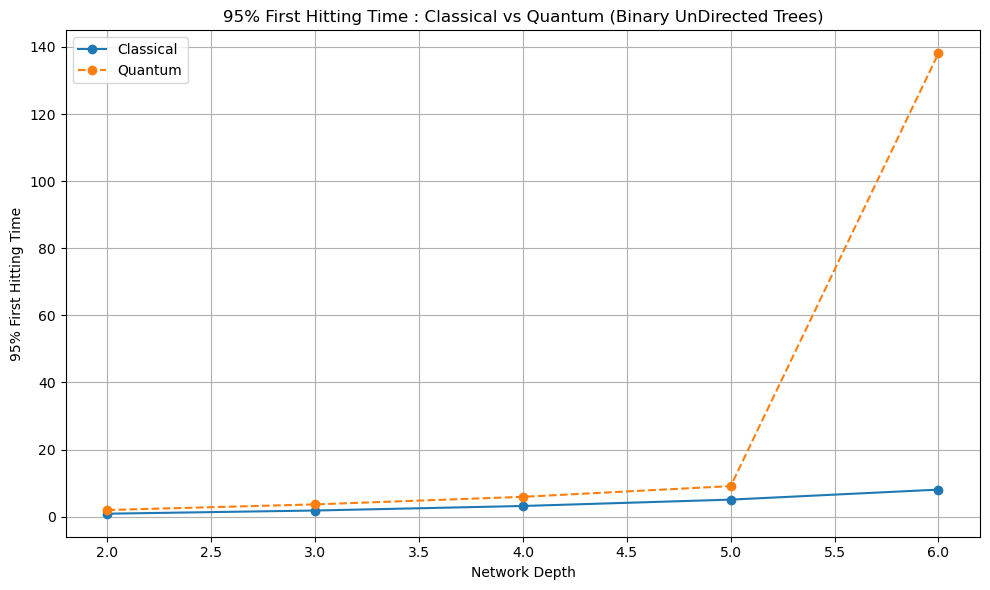

In [249]:
#plotting 2 to 5
# Prepare x (network depth) and y (95% first hitting time)
nDepth = sorted(classical.keys())
classical_orig = [classical[d] for d in nDepth]
quantum_orig   = [quantum[d]   for d in nDepth]

# Create single plot
plt.figure(figsize=(10, 6))
plt.plot(nDepth, classical_orig, marker='o', linestyle='-',  color='tab:blue',   label='Classical')
plt.plot(nDepth, quantum_orig,   marker='o', linestyle='--', color='tab:orange', label='Quantum')

plt.title('95% First Hitting Time : Classical vs Quantum (Binary UnDirected Trees)')
plt.xlabel('Network Depth')
plt.ylabel('95% First Hitting Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Reference Values obtained in past runs
#Calculated classical and quantum dictionaries (qwalk >> function01)
# Classical: {2: 0.87, 3: 1.82, 4: 3.17, 5: 5.07, 6: 8.05, 7: 18.5} 
# Quantum: {2: 39.99, 3: 39.99, 4: 39.99, 5: 39.99, 6: 39.99, 7: 39.99}


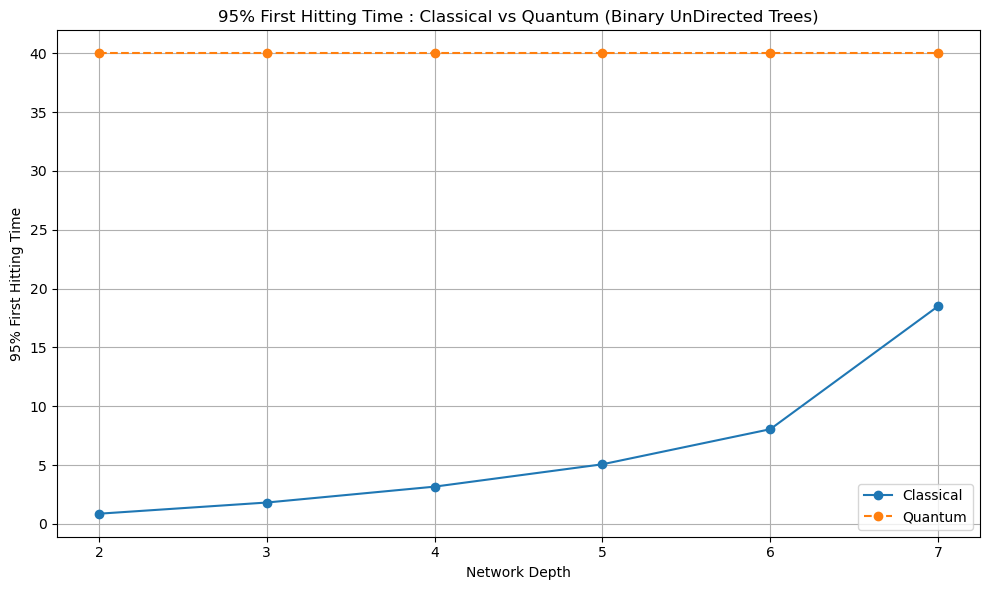

In [107]:
#plotting 2 to 7
# Prepare x (network depth) and y (95% first hitting time)
nDepth = sorted(classical.keys())
classical_orig = [classical[d] for d in nDepth]
quantum_orig   = [quantum[d]   for d in nDepth]

# Create single plot
plt.figure(figsize=(10, 6))
plt.plot(nDepth, classical_orig, marker='o', linestyle='-',  color='tab:blue',   label='Classical')
plt.plot(nDepth, quantum_orig,   marker='o', linestyle='--', color='tab:orange', label='Quantum')

plt.title('95% First Hitting Time : Classical vs Quantum (Binary UnDirected Trees)')
plt.xlabel('Network Depth')
plt.ylabel('95% First Hitting Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()